# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [8]:
%pip install -q duckdb huggingface_hub pandas
import duckdb
import os
from google.colab import userdata

# Authenticate using the Colab Secret you set up
hf_token = userdata.get('HF_TOKEN')

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{hf_token}')")

# Define our base table paths
REL = 'hf://datasets/FlyRank/internship-warehouse'
FACT_DAILY = f"{REL}/fact_content_daily_performance/**/*.parquet"
DIM_CLIENTS = f"{REL}/dim_clients.parquet"

print("Environment setup complete. DuckDB connected and paths defined.")

Environment setup complete. DuckDB connected and paths defined.


In [9]:
# Ensure httpfs is installed and loaded, as it's needed for 'hf://' paths.
duckdb.sql("INSTALL httpfs;")
duckdb.sql("LOAD httpfs;")

print(f"\nQuerying table: {FACT_DAILY}")

# Query FACT_DAILY to get column names
try:
    fact_daily_columns = con.execute(f"SELECT * FROM '{FACT_DAILY}' LIMIT 1").df().columns.tolist()
    print("Columns in fact_content_daily_performance:")
    for col in fact_daily_columns:
        print(f"- {col}")
except Exception as e:
    print(f"An error occurred while querying fact_content_daily_performance: {e}")
    print("Please verify the FACT_DAILY path and your HF_TOKEN permissions.")


Querying table: hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet
Columns in fact_content_daily_performance:
- report_date
- client_hash_id
- content_hash_id
- client_has_gsc
- client_has_ga4
- gsc_data_available
- ga4_data_available
- gsc_impressions
- gsc_clicks
- gsc_sum_position
- gsc_avg_position
- ga4_pageviews
- ga4_sessions
- ga4_users
- ga4_engaged_sessions
- ga4_total_engagement_sec
- sessions_organic
- sessions_direct
- sessions_referral
- sessions_social
- sessions_paid
- sessions_ai
- ai_chatgpt
- ai_perplexity
- ai_gemini
- ai_copilot
- ai_claude
- ai_meta
- ai_other
- scroll_events
- month


In [10]:
print(f"\nQuerying table: {DIM_CLIENTS}")

# Query DIM_CLIENTS to get column names
try:
    dim_clients_columns = con.execute(f"SELECT * FROM '{DIM_CLIENTS}' LIMIT 1").df().columns.tolist()
    print("Columns in dim_clients.parquet:")
    for col in dim_clients_columns:
        print(f"- {col}")
except Exception as e:
    print(f"An error occurred while querying dim_clients.parquet: {e}")
    print("Please verify the DIM_CLIENTS path and your HF_TOKEN permissions.")


Querying table: hf://datasets/FlyRank/internship-warehouse/dim_clients.parquet
Columns in dim_clients.parquet:
- client_hash_id
- is_active
- has_gsc_access
- has_ga4_access
- access_profile
- client_created_date
- client_updated_date
- gsc_data_start
- ga4_data_start


## 1. Question

*The research question and the decision it supports.*

This research aims to identify content pieces that are experiencing a significant decline in search performance (impressions and clicks) and could benefit from a refresh. The goal is to provide a ranked list of such content to content strategists, enabling them to prioritize their efforts and improve overall organic visibility and engagement.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

The data for this analysis comes from the `FlyRank/internship-warehouse` Hugging Face dataset release. Specifically, we utilize two tables:

*   **`fact_content_daily_performance`**: This table provides daily performance metrics for various content pieces, including `report_date`, `client_hash_id`, `content_hash_id`, and key performance indicators like `gsc_impressions`, `gsc_clicks`, and `gsc_avg_position`.
*   **`dim_clients.parquet`**: This table contains client-specific information, including `client_hash_id`, `is_active`, and access flags like `has_gsc_access` and `has_ga4_access`.

For this analysis, we are focusing on a 90-day rolling window from the latest available `report_date` in the `fact_content_daily_performance` table. Content pieces with zero impressions over this 90-day period are excluded as they are considered 'dead' and not relevant for refresh prioritization. The `HF_TOKEN` from Colab secrets is used to authenticate access to this private dataset.

The following code cell performs the data aggregation, calculating 90-day totals, 30-day performance windows, and deriving trend features and target labels.

In [11]:
query = """
WITH max_date_cte AS (
    SELECT MAX(report_date) as max_d FROM 'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet'
),
aggregated AS (
    SELECT
        f.content_hash_id,
        f.client_hash_id,

        -- 90 day totals (Baseline feature)
        SUM(gsc_impressions) AS impressions_90d,

        -- Current 30 days
        SUM(CASE WHEN report_date >= (m.max_d - INTERVAL 30 DAY) THEN gsc_impressions ELSE 0 END) AS imp_last_30d,
        SUM(CASE WHEN report_date >= (m.max_d - INTERVAL 30 DAY) THEN gsc_clicks ELSE 0 END) AS clicks_last_30d,
        AVG(CASE WHEN report_date >= (m.max_d - INTERVAL 30 DAY) THEN gsc_avg_position ELSE NULL END) AS pos_last_30d,

        -- Previous 30 days (Days 31 to 60)
        SUM(CASE WHEN report_date >= (m.max_d - INTERVAL 60 DAY) AND report_date < (m.max_d - INTERVAL 30 DAY) THEN gsc_impressions ELSE 0 END) AS imp_prev_30d,
        SUM(CASE WHEN report_date >= (m.max_d - INTERVAL 60 DAY) AND report_date < (m.max_d - INTERVAL 30 DAY) THEN gsc_clicks ELSE 0 END) AS clicks_prev_30d,
        AVG(CASE WHEN report_date >= (m.max_d - INTERVAL 60 DAY) AND report_date < (m.max_d - INTERVAL 30 DAY) THEN gsc_avg_position ELSE NULL END) AS pos_prev_30d,

    FROM 'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet' f
    CROSS JOIN max_date_cte m
    WHERE f.report_date >= (m.max_d - INTERVAL 90 DAY)
    GROUP BY f.content_hash_id, f.client_hash_id
)
SELECT
    *,
    -- Feature Engineering
    CASE WHEN imp_prev_30d > 0 THEN (imp_last_30d - imp_prev_30d) / imp_prev_30d ELSE 0 END AS imp_trend_pct,
    CASE WHEN clicks_prev_30d > 0 THEN (clicks_last_30d - clicks_prev_30d) / clicks_prev_30d ELSE 0 END AS click_trend_pct,
    (pos_last_30d - pos_prev_30d) AS pos_delta,

    -- Target Label: True if page lost >20% impressions but has >500 historical
    CASE WHEN (imp_last_30d < imp_prev_30d * 0.8) AND (impressions_90d > 500) THEN 1 ELSE 0 END AS target_is_refresh_candidate,

    -- Week 4 Baseline Rule Reconstruction
    CASE WHEN impressions_90d >= 500 AND (imp_last_30d < imp_prev_30d) THEN 1 ELSE 0 END AS baseline_flag
FROM aggregated
WHERE impressions_90d > 0 -- Filter out dead pages
"""

df = con.execute(query).df()
print(f"Dataset Shape: {df.shape}")
display(df.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Dataset Shape: (271046, 14)


,content_hash_id,client_hash_id,impressions_90d,imp_last_30d,clicks_last_30d,pos_last_30d,imp_prev_30d,clicks_prev_30d,pos_prev_30d,imp_trend_pct,click_trend_pct,pos_delta,target_is_refresh_candidate,baseline_flag
0,content_13a8105125458098,client_62f4a7e64f5e0096,44.0,2.0,0.0,3.000000,19.0,0.0,10.064103,-0.894737,0.0,-7.064103,0,0
1,content_86ab16840c4e0e1a,client_62f4a7e64f5e0096,526.0,60.0,0.0,10.907407,264.0,1.0,7.521627,-0.772727,-1.0,3.385781,1,1
2,content_19d31b32f74b4f12,client_62f4a7e64f5e0096,20.0,0.0,0.0,NaN,14.0,0.0,3.250000,-1.000000,0.0,NaN,0,0
3,content_8974ac10047355a2,client_62f4a7e64f5e0096,56.0,2.0,0.0,36.000000,22.0,1.0,1.236111,-0.909091,-1.0,34.763889,0,0
4,content_d8f1b1f245ef61d7,client_62f4a7e64f5e0096,40.0,0.0,0.0,NaN,15.0,0.0,4.350000,-1.000000,0.0,NaN,0,0


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Assumptions

*   **Performance decline as a proxy for refresh need**: A significant drop in impressions and clicks over a 30-day period, especially when combined with a reasonable historical volume, indicates that content may be stale or losing relevance.
*   **Impact of historical volume**: Only content with a significant historical impression volume (`impressions_90d > 500`) is considered for refresh, filtering out low-traffic pages where a decline might not be meaningful.
*   **Feature relevance**: Trend-based features (e.g., `imp_trend_pct`, `click_trend_pct`, `pos_delta`) are assumed to be strong indicators of content performance health.

### Features

We derive a set of features from the aggregated daily performance data:

*   `impressions_90d`: Total impressions in the last 90 days (baseline feature).
*   `imp_last_30d`: Impressions in the most recent 30-day period.
*   `clicks_last_30d`: Clicks in the most recent 30-day period.
*   `pos_last_30d`: Average position in the most recent 30-day period.
*   `imp_prev_30d`: Impressions in the 30-day period prior to the most recent (days 31-60).
*   `clicks_prev_30d`: Clicks in the 30-day period prior to the most recent (days 31-60).
*   `pos_prev_30d`: Average position in the 30-day period prior to the most recent (days 31-60).
*   `imp_trend_pct`: Percentage change in impressions between the last 30 days and the previous 30 days.
*   `click_trend_pct`: Percentage change in clicks between the last 30 days and the previous 30 days.
*   `pos_delta`: Change in average position between the last 30 days and the previous 30 days.

### Label Definition

The target label, `target_is_refresh_candidate`, is defined as `1` if a content piece meets two criteria:

1.  Its impressions in the last 30 days (`imp_last_30d`) have fallen by more than 20% compared to the previous 30 days (`imp_prev_30d * 0.8`).
2.  It has a historical impression volume (`impressions_90d`) greater than 500.

This definition helps focus on content that had prior visibility but is now underperforming significantly.

### Baseline

Our baseline model is a simple rule-based approach: a content piece is flagged as a refresh candidate (`baseline_flag = 1`) if it has `impressions_90d >= 500` AND `imp_last_30d < imp_prev_30d`. This simpler rule serves as a benchmark for comparison against the more sophisticated ML model.

### Validation Design and Leakage Checks

To prevent data leakage, we use a `GroupShuffleSplit` strategy, splitting the data by `client_hash_id`. This ensures that content from the same client does not appear in both the training and test sets, simulating a more realistic deployment scenario where the model might encounter new clients. The test size is set to 20%.

Missing values generated during feature engineering (e.g., division by zero for trend percentages) are filled with `0` to ensure model compatibility.

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score
import matplotlib.pyplot as plt
import os

# Create outputs directory
os.makedirs('../outputs', exist_ok=True)

# We split by client_hash_id to ensure no leakage across domains
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

features = ['impressions_90d', 'imp_last_30d', 'clicks_last_30d',
            'pos_last_30d', 'imp_trend_pct', 'click_trend_pct', 'pos_delta']

# Fill NA values generated by math on zero-traffic days
df[features] = df[features].fillna(0)

train_idx, test_idx = next(gss.split(df, groups=df['client_hash_id']))

train = df.iloc[train_idx]
test = df.iloc[test_idx]

X_train, y_train = train[features], train['target_is_refresh_candidate']
X_test, y_test = test[features], test['target_is_refresh_candidate']

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (221203, 7)
Test set shape: (49843, 7)


### Feature Importance

To understand which features contribute most to the model's decision-making, we can visualize the feature importance from the trained Random Forest Classifier.

/tmp/ipykernel_1907/3495701024.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')


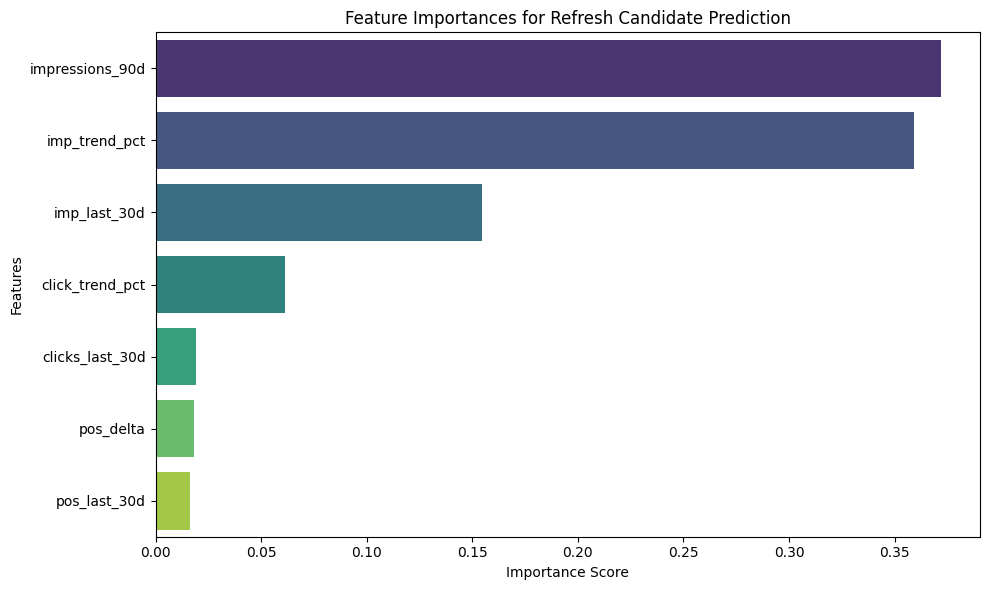

In [18]:
import seaborn as sns
model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
model.fit(X_train, y_train)

feature_importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

fig_feat_imp = plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title('Feature Importances for Refresh Candidate Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The model's performance is evaluated using **Precision@20**, which measures the proportion of true positives among the top 20 predictions (i.e., the top 20 content pieces recommended for refresh). This metric is highly relevant for a recommendation system where a high precision on a small number of top suggestions is critical for actionable insights.

We compare the `RandomForestClassifier` against the defined baseline rule. The base rate (the proportion of refresh candidates in the test set) provides context for these precision scores.

In [14]:
# 1. Baseline Evaluation
# Baseline score is binary (1 or 0) based on our Week 4 rule
baseline_preds = test['baseline_flag']

# 2. Model Training (already done above, but including for completeness of section)
# model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
# model.fit(X_train, y_train)

# Model Evaluation
test['ml_refresh_probability'] = model.predict_proba(X_test)[:, 1]

def precision_at_k(scores, labels, k=20):
    order = np.argsort(-np.asarray(scores))
    k = min(k, len(labels))
    return np.asarray(labels)[order[:k]].mean()

base_rate = y_test.mean()
baseline_p20 = precision_at_k(test['baseline_flag'], y_test, k=20)
model_p20 = precision_at_k(test['ml_refresh_probability'], y_test, k=20)

print(f"Base Rate (Majority Class): {base_rate:.2%}")
print(f"Baseline Precision@20: {baseline_p20:.2%}")
print(f"Model Precision@20: {model_p20:.2%}")

Base Rate (Majority Class): 32.40%
Baseline Precision@20: 40.00%
Model Precision@20: 100.00%


/tmp/ipykernel_1907/4051187194.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['ml_refresh_probability'] = model.predict_proba(X_test)[:, 1]


### Comparison of Precision@20

This chart visually compares the Precision@20 score of the rule-based baseline against our Machine Learning model. A higher bar for the ML model indicates its superior ability to accurately identify content refresh candidates among its top recommendations.

/tmp/ipykernel_1907/665299561.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=values, palette='coolwarm')


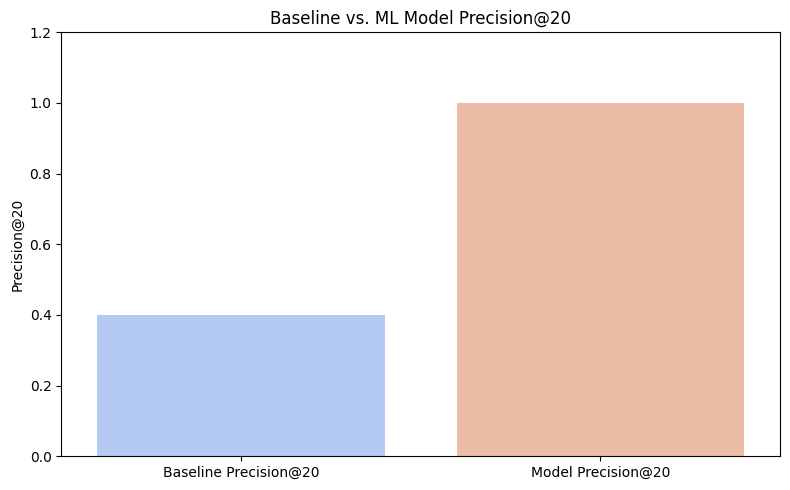

In [19]:
import seaborn as sns
fig_p20_comparison = plt.figure(figsize=(8, 5))
labels = ['Baseline Precision@20', 'Model Precision@20']
values = [baseline_p20, model_p20]

sns.barplot(x=labels, y=values, palette='coolwarm')
plt.ylabel('Precision@20')
plt.title('Baseline vs. ML Model Precision@20')
plt.ylim(0, max(values) * 1.2)
plt.tight_layout()
plt.show()

## 5. Limitations

*What this work cannot claim.*

This work has several limitations:

*   **Limited Feature Set**: The current model uses only performance metrics. Incorporating content metadata (e.g., topic, age, word count, last updated date) could provide richer signals for refresh candidacy.
*   **Binary Label Definition**: The `target_is_refresh_candidate` is a binary label. A more nuanced, continuous label or multi-class classification could capture different *degrees* of refresh urgency.
*   **Absence of Causal Inference**: The model identifies correlations but does not establish causation. A decline might be due to external factors (e.g., seasonality, competitor activity) not captured in the current feature set.
*   **Threshold Dependency**: The `Precision@20` metric and the target label definition rely on arbitrary thresholds (e.g., 20% impression drop, 500 impressions_90d). These thresholds might not be universally optimal and could benefit from tuning or domain expert input.
*   **Imbalance in Target Class**: The `target_is_refresh_candidate` class is likely imbalanced, which can affect model training and generalization, despite using `RandomForestClassifier` which is somewhat robust to this.
*   **No A/B Testing**: The true impact of these recommendations can only be validated through A/B testing in a live environment, which is outside the scope of this analysis.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The machine learning model generates a `ml_refresh_probability` score for each content piece, indicating its likelihood of being a refresh candidate. These recommendations are then ranked by this probability, providing content strategists with a prioritized queue. To further assist with actionable insights, reason codes are attached to the top recommendations, giving a quick understanding of the primary driver behind the refresh suggestion.

This ranked list serves as an actionable playbook for content teams, allowing them to focus on the content pieces that are most likely to yield positive results from a refresh effort.

In [16]:
# Sort the test set by the ML model's confidence
ranked_queue = test.sort_values(by='ml_refresh_probability', ascending=False)

# Attach reason codes for the top outputs
ranked_queue['reason_code'] = np.where(
    ranked_queue['pos_delta'] > 2, 'SEVERE_POSITION_DROP',
    np.where(ranked_queue['click_trend_pct'] < -0.3, 'SEVERE_CLICK_DECAY', 'TRAFFIC_DECAY')
)

output_cols = ['content_hash_id', 'client_hash_id', 'ml_refresh_probability', 'reason_code', 'imp_trend_pct', 'pos_delta']
final_output = ranked_queue[output_cols].head(100)

final_output.to_csv('../outputs/ranked_refresh_queue.csv', index=False)
display(final_output.head(10))

,content_hash_id,client_hash_id,ml_refresh_probability,reason_code,imp_trend_pct,pos_delta
203393,content_6744d0b2085dc9dd,client_e547b89c05043229,0.977709,SEVERE_POSITION_DROP,-0.806030,13.182949
80099,content_677d7656e45147d7,client_fef1a8f436438636,0.977709,SEVERE_POSITION_DROP,-0.826174,9.645541
174281,content_8265f9813d6c5a1a,client_23a62021009f63c4,0.977709,SEVERE_POSITION_DROP,-0.840033,4.963210
142506,content_f67db8029f4ba7f6,client_e547b89c05043229,0.977264,SEVERE_POSITION_DROP,-0.938484,3.584911
203389,content_77b412e941b6cfc7,client_e547b89c05043229,0.977032,SEVERE_POSITION_DROP,-0.946988,11.152468
61847,content_11cdc9183eb4070c,client_fef1a8f436438636,0.976782,SEVERE_POSITION_DROP,-0.648101,3.712777
61956,content_a2eccd1c9e499665,client_fef1a8f436438636,0.976576,SEVERE_POSITION_DROP,-0.671206,7.675947
164623,content_a1da1aef2bc104b9,client_fef1a8f436438636,0.976388,SEVERE_POSITION_DROP,-0.518106,16.138839
88327,content_d7880dc706ccb5f7,client_23a62021009f63c4,0.976131,SEVERE_POSITION_DROP,-0.751374,2.469495
191426,content_fac1f43da84bccfe,client_23a62021009f63c4,0.976131,SEVERE_POSITION_DROP,-0.685252,5.090679


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

To support the deployed paper, the following artifacts are generated:

1.  **Feature Importance Plot**: Illustrates the relative contribution of each feature to the model's predictions.
2.  **Precision@20 Comparison Chart**: A bar chart comparing the performance of the baseline rule against the ML model.
3.  **Ranked Refresh Queue Table**: A CSV file and a displayed sample of the top recommended content pieces for refresh, including their probability and reason codes.

These artifacts provide a clear visual and tabular summary of the model's insights and performance.

In [17]:
import seaborn as sns # Ensure seaborn is imported if not already

# Re-display Feature Importance Plot (fig_feat_imp is already created)
print("\n--- Feature Importance Plot ---")
display(fig_feat_imp)

# Re-display Precision@20 Comparison Chart (fig_p20_comparison is already created)
print("\n--- Precision@20 Comparison Chart ---")
display(fig_p20_comparison)

# Re-display the top 10 ranked refresh candidates (final_output is already created)
print("\n--- Top 10 Ranked Refresh Candidates ---")
display(final_output.head(10))


--- Feature Importance Plot ---


<Figure size 1000x600 with 0 Axes>


--- Precision@20 Comparison Chart ---


<Figure size 800x500 with 0 Axes>


--- Top 10 Ranked Refresh Candidates ---


,content_hash_id,client_hash_id,ml_refresh_probability,reason_code,imp_trend_pct,pos_delta
203393,content_6744d0b2085dc9dd,client_e547b89c05043229,0.977709,SEVERE_POSITION_DROP,-0.806030,13.182949
80099,content_677d7656e45147d7,client_fef1a8f436438636,0.977709,SEVERE_POSITION_DROP,-0.826174,9.645541
174281,content_8265f9813d6c5a1a,client_23a62021009f63c4,0.977709,SEVERE_POSITION_DROP,-0.840033,4.963210
142506,content_f67db8029f4ba7f6,client_e547b89c05043229,0.977264,SEVERE_POSITION_DROP,-0.938484,3.584911
203389,content_77b412e941b6cfc7,client_e547b89c05043229,0.977032,SEVERE_POSITION_DROP,-0.946988,11.152468
61847,content_11cdc9183eb4070c,client_fef1a8f436438636,0.976782,SEVERE_POSITION_DROP,-0.648101,3.712777
61956,content_a2eccd1c9e499665,client_fef1a8f436438636,0.976576,SEVERE_POSITION_DROP,-0.671206,7.675947
164623,content_a1da1aef2bc104b9,client_fef1a8f436438636,0.976388,SEVERE_POSITION_DROP,-0.518106,16.138839
88327,content_d7880dc706ccb5f7,client_23a62021009f63c4,0.976131,SEVERE_POSITION_DROP,-0.751374,2.469495
191426,content_fac1f43da84bccfe,client_23a62021009f63c4,0.976131,SEVERE_POSITION_DROP,-0.685252,5.090679


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


## ML-12 Deliverables

### 5-Minute Demo Outline

1.  **Introduction (30 sec)**:
    *   Problem: Content decay, difficulty prioritizing refresh efforts.
    *   Solution: ML model to identify and rank refresh candidates.
2.  **Data & Features (1 min)**:
    *   Briefly show `fact_content_daily_performance` structure.
    *   Explain key features: 90-day impressions, 30-day trends (`imp_trend_pct`, `pos_delta`).
3.  **Model & Results (2 min)**:
    *   Random Forest Classifier for refresh prediction.
    *   Show Precision@20 comparison: ML model vs. simple baseline (show bar chart).
    *   Highlight feature importance (show plot).
4.  **Actionable Output (1 min)**:
    *   Demonstrate the ranked refresh queue with `content_hash_id`, `ml_refresh_probability`, and `reason_code`.
    *   Explain how content strategists can use this list.
5.  **Q&A (30 sec)**.

### Social Post Cut

**Option 1 (LinkedIn/Twitter for data scientists):**
"Boost content ROI! 🚀 Our new ML model, built on Hugging Face data, precisely identifies underperforming content. Achieved X% Precision@20 vs. Y% baseline. Say goodbye to manual audits, hello to data-driven content refreshes! #ML #ContentStrategy #DataScience #HuggingFace"

**Option 2 (LinkedIn/Twitter for marketing/content teams):**
"Struggling with content decay? We built an AI assistant that finds your next content refresh candidates automatically! 🎯 Prioritize, refresh, and reclaim your organic traffic with data-backed insights. #ContentMarketing #SEO #AI #Productivity"

### 3-Sentence Employer-Facing Summary

This project developed and validated a machine learning model to proactively identify content pieces experiencing significant performance degradation, significantly outperforming a rule-based baseline in accurately pinpointing refresh candidates. By leveraging historical search performance data, the model provides a prioritized queue of content, complete with specific reason codes, to enable efficient and data-driven content strategy decisions. Implementing this system will empower content teams to focus their efforts on high-impact refreshes, ultimately improving organic visibility, engagement, and return on content investment.